# 01 - Exploratory Data Analysis (EDA)
**Goal:** understand the credit card default data *before* modelling: size, balance, data quality, and which customer details relate to default.

Dataset: 30,000 credit card clients (UCI "Default of Credit Card Clients", Taiwan). Target `default` = 1 if the client missed the next month's payment.

All charts are also saved as PNG files in `results/eda/` for the project report.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))   # so we can import from src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data_preprocessing import load_raw_data, clean_data

FIG_DIR = config.RESULTS_DIR / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save(name):
    """Tidy the figure, save it to results/eda/, then show it."""
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=120)
    plt.show()

sns.set_theme(style="whitegrid")

## 1. Size, types and missing values

In [2]:
raw = load_raw_data()
print("Rows, columns:", raw.shape)
print("Missing values:", int(raw.isna().sum().sum()))
print("Duplicate rows:", int(raw.duplicated().sum()))
raw.dtypes.value_counts()

Rows, columns: (30000, 25)
Missing values: 0
Duplicate rows: 0


int64    25
Name: count, dtype: int64

In [3]:
raw.describe().T[["mean", "std", "min", "50%", "max"]].round(1)

,mean,std,min,50%,max
ID,15000.5,8660.4,1.0,15000.5,30000.0
LIMIT_BAL,167484.3,129747.7,10000.0,140000.0,1000000.0
SEX,1.6,0.5,1.0,2.0,2.0
EDUCATION,1.9,0.8,0.0,2.0,6.0
MARRIAGE,1.6,0.5,0.0,2.0,3.0
AGE,35.5,9.2,21.0,34.0,79.0
PAY_0,-0.0,1.1,-2.0,0.0,8.0
PAY_2,-0.1,1.2,-2.0,0.0,8.0
PAY_3,-0.2,1.2,-2.0,0.0,8.0
PAY_4,-0.2,1.2,-2.0,0.0,8.0


## 2. How many customers default? (class balance)
This matters because a model that always says "no default" would already be right ~78% of the time, so accuracy alone is misleading. We will use ROC-AUC and PR-AUC instead.

{0: 23364, 1: 6636} -> default rate = 22.1%


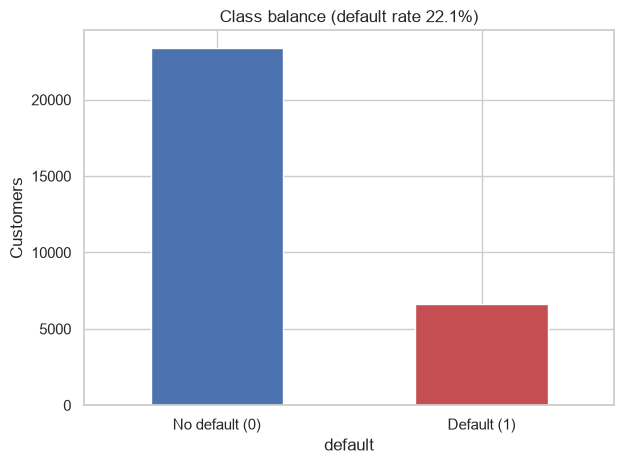

In [4]:
counts = raw["default"].value_counts().sort_index()
rate = raw["default"].mean()
print(counts.to_dict(), f"-> default rate = {rate:.1%}")

ax = counts.plot(kind="bar", color=["#4C72B0", "#C44E52"], rot=0)
ax.set_xticklabels(["No default (0)", "Default (1)"])
ax.set_title(f"Class balance (default rate {rate:.1%})")
ax.set_ylabel("Customers")
save("01_class_balance")

## 3. Data quality: undocumented category codes
The dataset description only defines EDUCATION = 1-4 and MARRIAGE = 1-3, but the file also contains other codes. `clean_data()` groups them into "others".

In [5]:
print("EDUCATION codes:", raw["EDUCATION"].value_counts().sort_index().to_dict())
print("MARRIAGE codes :", raw["MARRIAGE"].value_counts().sort_index().to_dict())

odd_edu = raw["EDUCATION"].isin([0, 5, 6]).sum()
odd_mar = (raw["MARRIAGE"] == 0).sum()
print(f"Undocumented codes: {odd_edu} rows in EDUCATION, {odd_mar} rows in MARRIAGE")

EDUCATION codes: {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
MARRIAGE codes : {0: 54, 1: 13659, 2: 15964, 3: 323}
Undocumented codes: 345 rows in EDUCATION, 54 rows in MARRIAGE


In [6]:
df = clean_data(raw)          # drops ID, groups unknown codes
print("After cleaning:", df.shape)
print("EDUCATION:", sorted(df["EDUCATION"].unique()), "| MARRIAGE:", sorted(df["MARRIAGE"].unique()))

After cleaning: (30000, 24)
EDUCATION: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)] | MARRIAGE: [np.int64(1), np.int64(2), np.int64(3)]


## 4. Who are the customers? (credit limit and age)

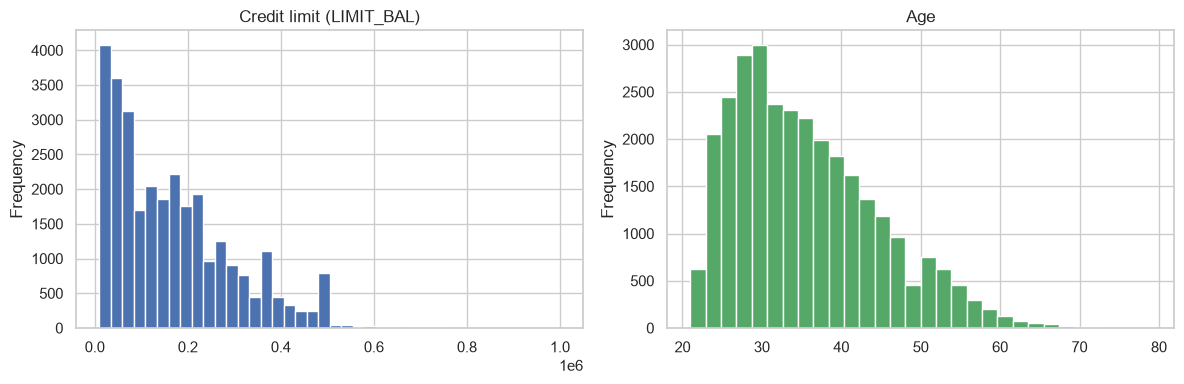

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["LIMIT_BAL"].plot(kind="hist", bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Credit limit (LIMIT_BAL)")
df["AGE"].plot(kind="hist", bins=30, ax=axes[1], color="#55A868")
axes[1].set_title("Age")
save("02_limit_and_age_distribution")

## 5. Default rate by customer group
SEX, EDUCATION and MARRIAGE are **sensitive attributes** in real lending. We look at them to understand the data and to flag fairness risks, not because we want to build decisions on them.

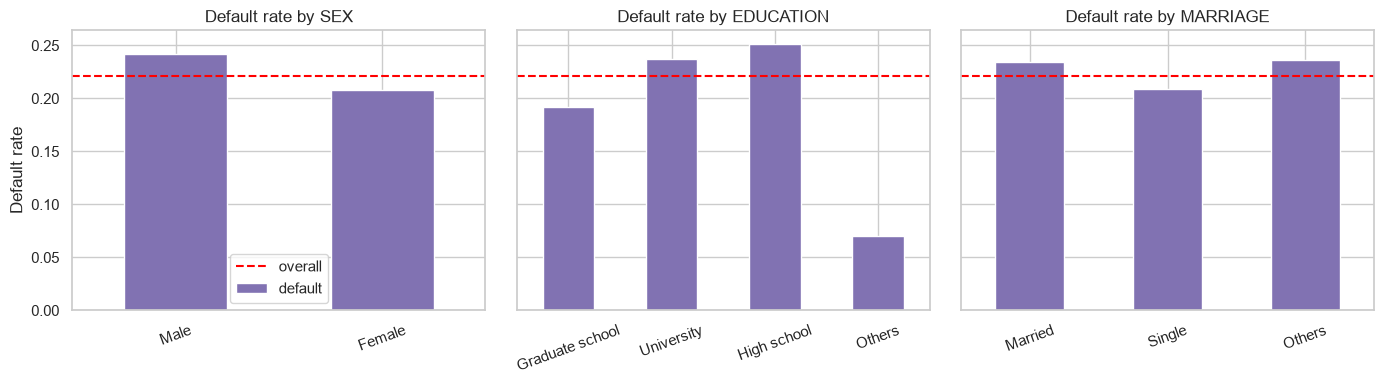

SEX {'Male': 0.242, 'Female': 0.208}
EDUCATION {'Graduate school': 0.192, 'University': 0.237, 'High school': 0.252, 'Others': 0.071}
MARRIAGE {'Married': 0.235, 'Single': 0.209, 'Others': 0.236}


In [8]:
labels = {
    "SEX": {1: "Male", 2: "Female"},
    "EDUCATION": {1: "Graduate school", 2: "University", 3: "High school", 4: "Others"},
    "MARRIAGE": {1: "Married", 2: "Single", 3: "Others"},
}
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, col in zip(axes, labels):
    r = df.groupby(col)["default"].mean().rename(index=labels[col])
    r.plot(kind="bar", ax=ax, color="#8172B2", rot=20)
    ax.axhline(df["default"].mean(), color="red", ls="--", label="overall")
    ax.set_title(f"Default rate by {col}")
    ax.set_xlabel("")
axes[0].set_ylabel("Default rate")
axes[0].legend()
save("03_default_rate_by_group")

for col in labels:
    print(col, df.groupby(col)["default"].mean().rename(index=labels[col]).round(3).to_dict())

## 6. Repayment history: the strongest signal
`PAY_0` is the repayment status in the most recent month: -2/-1 = paid in full/on time, 0 = revolving credit, 1 = one month late, 2 = two months late, and so on.

       count   mean
PAY_0              
-2      2759  0.132
-1      5686  0.168
 0     14737  0.128
 1      3688  0.339
 2      2667  0.691
 3       322  0.758
 4        76  0.684
 5        26  0.500
 6        11  0.545
 7         9  0.778
 8        19  0.579


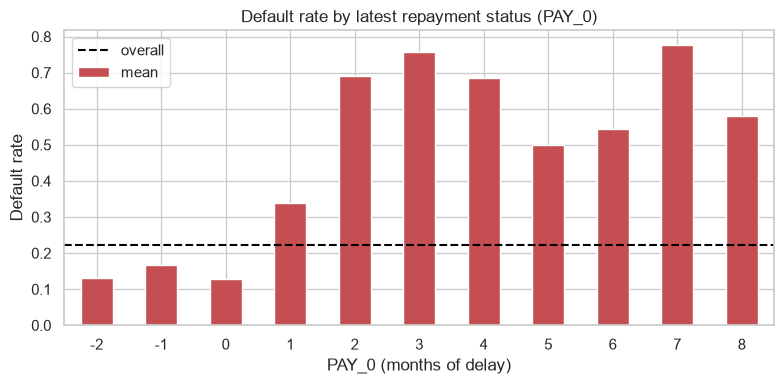

In [9]:
pay = df.groupby("PAY_0")["default"].agg(["count", "mean"]).round(3)
print(pay)

ax = pay["mean"].plot(kind="bar", color="#C44E52", rot=0, figsize=(8, 4))
ax.axhline(df["default"].mean(), color="black", ls="--", label="overall")
ax.set_title("Default rate by latest repayment status (PAY_0)")
ax.set_xlabel("PAY_0 (months of delay)")
ax.set_ylabel("Default rate")
ax.legend()
save("04_default_rate_by_pay0")

## 7. Credit limit, age and bill behaviour

C:\Users\Ananya\AppData\Local\Temp\ipykernel_32120\2448261779.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["No default", "Default"])


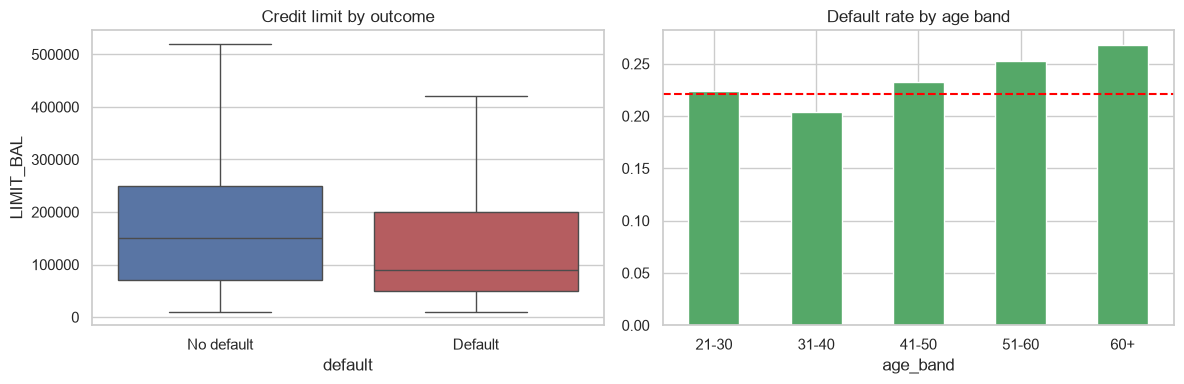

default
0    150000.0
1     90000.0
Name: LIMIT_BAL, dtype: float64
Customers with a negative bill in at least one month: 6.4%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="default", y="LIMIT_BAL", ax=axes[0], showfliers=False, palette=["#4C72B0", "#C44E52"], hue="default", legend=False)
axes[0].set_title("Credit limit by outcome")
axes[0].set_xticklabels(["No default", "Default"])

df["age_band"] = pd.cut(df["AGE"], [20, 30, 40, 50, 60, 80], labels=["21-30", "31-40", "41-50", "51-60", "60+"])
df.groupby("age_band", observed=True)["default"].mean().plot(kind="bar", ax=axes[1], color="#55A868", rot=0)
axes[1].axhline(df["default"].mean(), color="red", ls="--")
axes[1].set_title("Default rate by age band")
save("05_limit_and_age_vs_default")

print(df.groupby("default")["LIMIT_BAL"].median())
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
print(f"Customers with a negative bill in at least one month: {(df[bill_cols] < 0).any(axis=1).mean():.1%}")

## 8. Correlation with default

PAY_0        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
LIMIT_BAL   -0.154
PAY_AMT1    -0.073
PAY_AMT2    -0.059
PAY_AMT4    -0.057
Name: default, dtype: float64


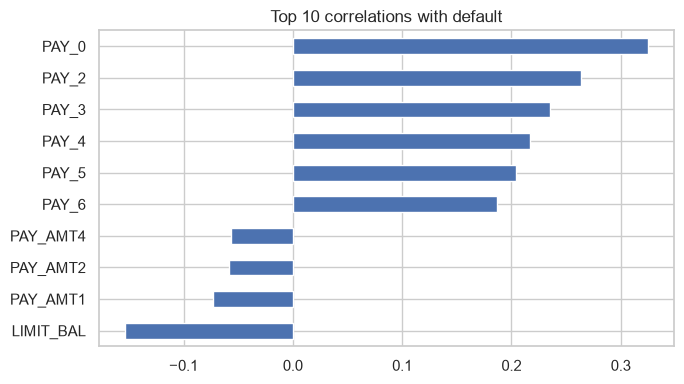

In [11]:
corr_target = df.drop(columns="age_band").corr()["default"].drop("default").sort_values(key=abs, ascending=False)
print(corr_target.head(10).round(3))

corr_target.head(10).sort_values().plot(kind="barh", figsize=(7, 4), color="#4C72B0")
plt.title("Top 10 correlations with default")
save("06_top_correlations")

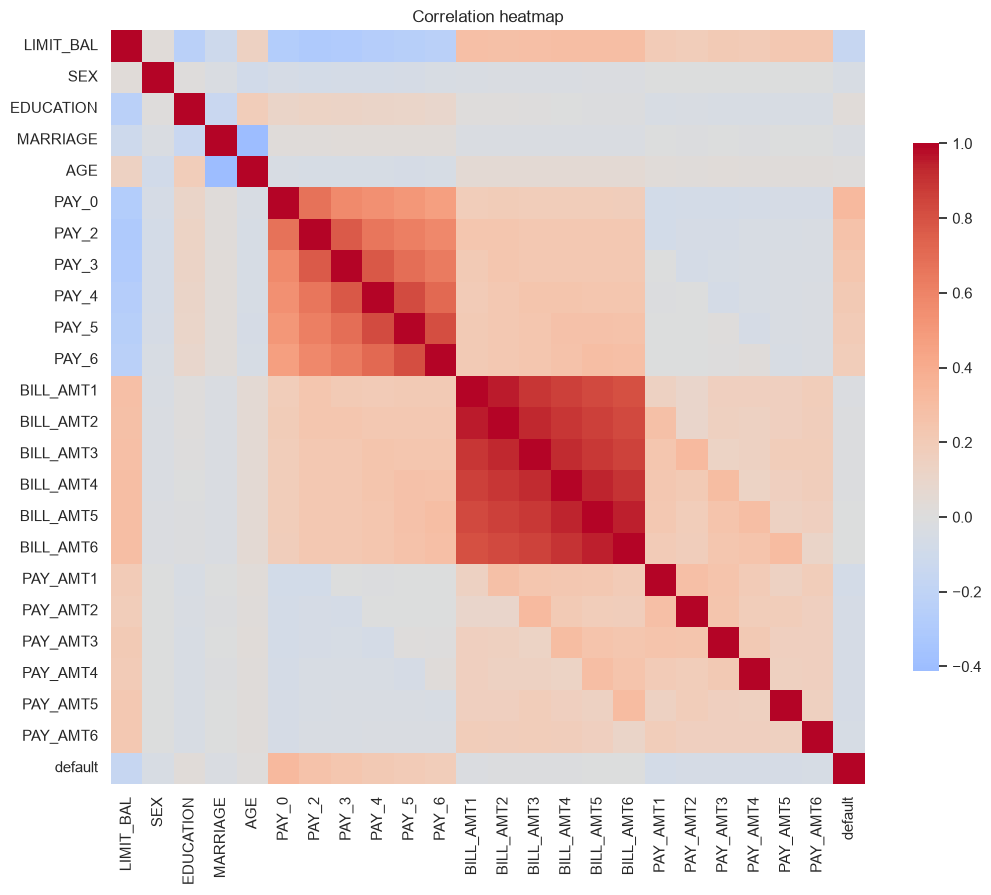

In [12]:
plt.figure(figsize=(11, 9))
sns.heatmap(df.drop(columns="age_band").corr(), cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.7})
plt.title("Correlation heatmap")
save("07_correlation_heatmap")

## 9. Key findings

1. **Size and quality:** 30,000 customers, no missing values. Only about **22.1% default**, so the data is imbalanced and accuracy alone is a poor measure.
2. **Undocumented codes:** 345 rows in EDUCATION (codes 0, 5, 6) and 54 in MARRIAGE (code 0) are not in the data description, so they are grouped into "others".
3. **Repayment history dominates:** customers two months late in the latest month (`PAY_0 = 2`) default about **69%** of the time, against roughly **13%** for customers on revolving credit (`PAY_0 = 0`). `PAY_0`, `PAY_2` and `PAY_3` are the three features most correlated with default.
4. **Credit limit:** the median limit is **90,000** for defaulters versus **150,000** for non-defaulters, so lower limits go with higher risk.
5. **Demographics differ a little:** default rates are about 24.2% for men and 20.8% for women, and 19.2% for graduate-school customers versus 25.2% for high-school customers. These are **sensitive attributes**, so they go in the project's fairness risk list.
6. **Negative bills:** about 6.4% of customers have a negative bill in at least one month (they overpaid), so ratio features need a safe denominator. `add_features()` already handles this.

**Next step:** train and compare several models (`src/train_model.py`).